In [2]:
#using logistic regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
df=pd.read_csv("heartdisease.csv")
df.head(5)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print(df.shape)

(920, 16)


In [4]:
print(df.info)

<bound method DataFrame.info of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False

In [5]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [6]:
df=df.fillna(df.mode().iloc[0])
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
encoder=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=encoder.fit_transform(df[col])
df["num"]=df["num"].apply(lambda x:0 if x==0 else 1)

C:\Users\win\AppData\Local\Temp\ipykernel_11652\4033057903.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.fillna(df.mode().iloc[0])


In [7]:
x=df.drop("num",axis=1)
y=df['num']
scaler=StandardScaler()
x=scaler.fit_transform(x)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=100)
model.fit(xtrain,ytrain)
ypred=model.predict(xtest)

In [8]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.metrics import confusion_matrix,roc_curve,roc_auc_score
acc=accuracy_score(ytest,ypred)
pre=precision_score(ytest,ypred)
rc=recall_score(ytest,ypred)
print("accuracy score",acc)
print("precision score",pre)
print("recall score",rc)

accuracy score 0.7880434782608695
precision score 0.8645833333333334
recall score 0.7614678899082569


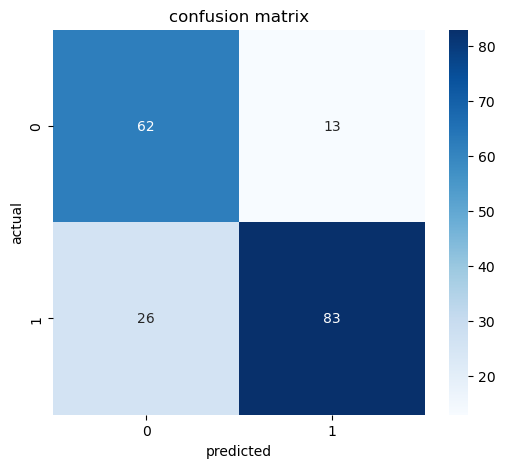

In [9]:
cm=confusion_matrix(ytest,ypred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

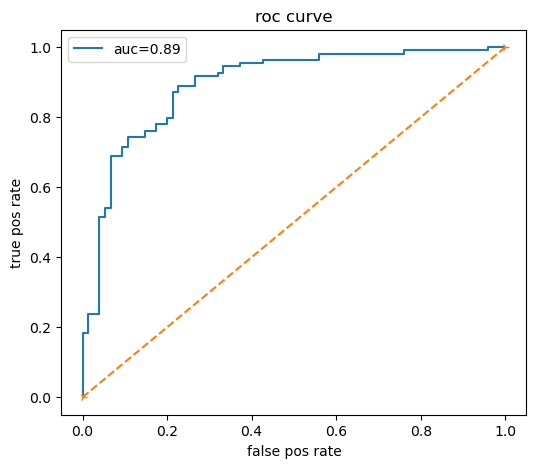

In [10]:
yprob=model.predict_proba(xtest)[:,1]
fpr,tpr,threshold=roc_curve(ytest,yprob)
auc=roc_auc_score(ytest,yprob)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label="auc=%.2f"%auc)
plt.plot([0,1],[0,1],'4--')
plt.title("roc curve")
plt.xlabel("false pos rate")
plt.ylabel("true pos rate")
plt.legend()
plt.show()

In [11]:
sample=xtest[0].reshape(1,-1)
predic=model.predict(sample)
if predic[0]==0:
    print("\n No heart disease")
else:
    print("\nHeart disease")


 No heart disease


In [13]:
#using decision tree classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

model.fit(xtrain,ytrain)
ypred = model.predict(xtest)

accuracy = accuracy_score(ytest, ypred)
precision = precision_score(ytest, ypred)
recall = recall_score(ytest, ypred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


Accuracy : 0.8206521739130435
Precision: 0.9042553191489362
Recall   : 0.7798165137614679


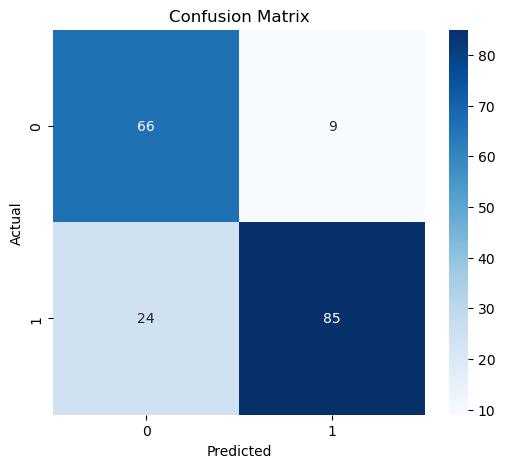

In [15]:
cm = confusion_matrix(ytest, ypred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


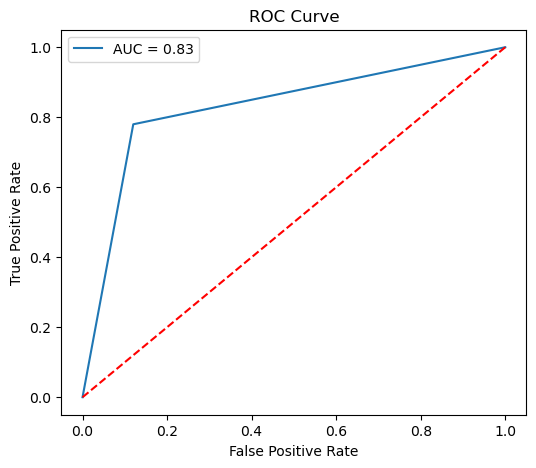

In [16]:
y_prob = model.predict_proba(xtest)[:,1]

fpr, tpr, thresholds = roc_curve(ytest, y_prob)
auc = roc_auc_score(ytest, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %.2f" % auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [17]:
sample = xtest[0].reshape(1,-1)

prediction = model.predict(sample)

if prediction[0] == 0:
    print("\nPrediction: No Heart Disease")
else:
    print("\nPrediction: Heart Disease")


Prediction: No Heart Disease
